### Pacotes importados

In [4]:
# codigo aqui

## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

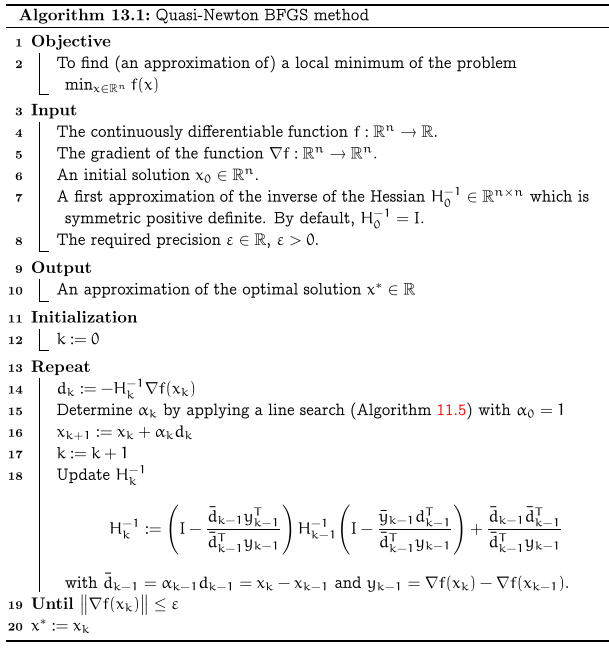

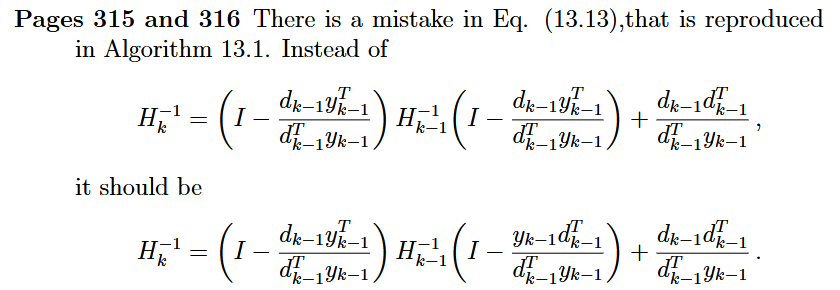

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

=== Algoritmo 13.1 — Quasi-Newton BFGS ===
f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]

k 	 x1 			 x2 			 ||∇f|| 		 f(xk)
0 	 +1.00000000E+00 	 +1.00000000E+00 	 +1.75516512E+00 	 +1.04030231E+00
1 	 -5.40302306E-01 	 +1.84147098E+00 	 +9.60941818E-01 	 +2.90430181E-01
2 	 -1.89009260E-02 	 +1.50527762E+00 	 +5.02450348E-02 	 -1.05885587E-03
3 	 -1.72233428E+00 	 +3.21510659E-01 	 +9.45851576E-01 	 -1.50862690E-01
4 	 -1.03582263E+00 	 +7.52251618E-01 	 +7.70948007E-01 	 -2.19843937E-01
5 	 -9.64184573E-01 	 -3.38800652E-02 	 +4.80485996E-02 	 -4.98805307E-01
6 	 -9.93582493E-01 	 -9.32933578E-03 	 +1.12493654E-02 	 -4.99936169E-01
7 	 -9.98564595E-01 	 +2.26183333E-03 	 +2.67474409E-03 	 -4.99996416E-01
8 	 -1.00123508E+00 	 -5.34534886E-04 	 +1.34618353E-03 	 -4.99999094E-01
9 	 -9.99961172E-01 	 -3.47210004E-05 	 +5.20869463E-05 	 -4.99999999E-01
10 	 -1.00000142E+00 	 +3.57636862E-06 	 +3.84741415E-06 	 -5.00000000E-01
11 	 -1.00000002E+00 	 -1.66661524E-08 	 +2.29012899E-08

┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:42
┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:42
┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:42
┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:42


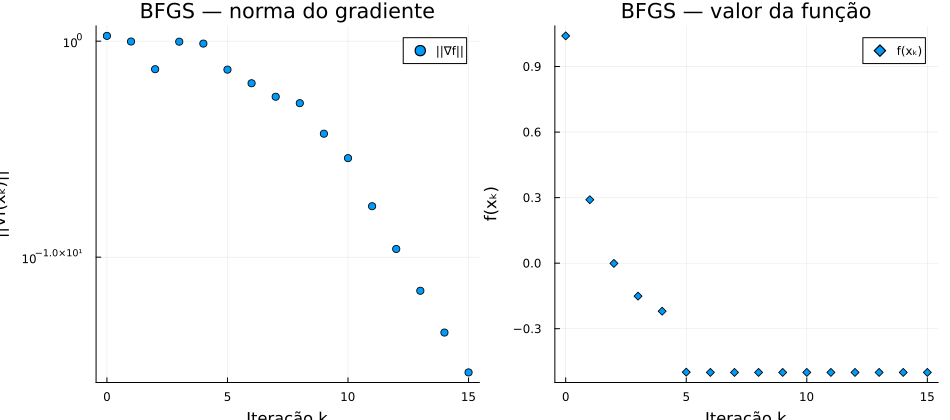

In [5]:
# Algoritmo 13.1 - Quasi-Newton BFGS
# f(x1, x2) = (1/2)x1² + x1·cos(x2)
# x₀ = [1.0, 1.0], H₀⁻¹ = I, ε = 1e-15

using LinearAlgebra
using Printf
using Plots

# ── Funções ───────────────────────────────────────────────────────────────
f(x)  = 0.5*x[1]^2 + x[1]*cos(x[2])

function ∇f(x)
    return [
        x[1] + cos(x[2]),
       -x[1]*sin(x[2])
    ]
end

# ── Line Search (Alg. 11.5 — Wolfe) ──────────────────────────────────────
function line_search(f, ∇f, x, d; α₀=1.0, β₁=1e-4, β₂=0.99, λ=2.0)
    slope = ∇f(x)' * d
    slope >= 0 && error("d não é direção de descida: ∇fᵀd = $slope")
    αl = 0.0; αr = Inf; α = α₀
    fx = f(x)
    for _ in 1:500
        ok_armijo    = f(x + α*d) <= fx + β₁*α*slope
        ok_curvatura = ∇f(x + α*d)'*d >= β₂*slope
        ok_armijo && ok_curvatura && return α
        if !ok_armijo
            αr = α; α = (αl + αr) / 2.0
        else
            αl = α; α = αr < Inf ? (αl + αr) / 2.0 : λ*α
        end
    end
    return α
end

# ── Atualização BFGS (fórmula CORRIGIDA) ─────────────────────────────────
function bfgs_update(Hinv, d, y)
    dy = d' * y
    if abs(dy) < 1e-14
        @warn "dᵀy ≈ 0 — pulando atualização BFGS"
        return Hinv
    end
    n  = length(d)
    I  = Matrix{Float64}(LinearAlgebra.I, n, n)
    # Fórmula CORRIGIDA (nota do enunciado):
    # Hk⁻¹ = (I - d·yᵀ/dᵀy) · Hk-1⁻¹ · (I - y·dᵀ/dᵀy) + d·dᵀ/dᵀy
    A    = I - (d * y') / dy
    B    = I - (y * d') / dy
    return A * Hinv * B + (d * d') / dy
end

# ── Algoritmo 13.1 — BFGS ────────────────────────────────────────────────
x     = [1.0, 1.0]
n     = length(x)
Hinv  = Matrix{Float64}(LinearAlgebra.I, n, n)   # H₀⁻¹ = I
ε     = 1e-15
k     = 0
maxiter = 1000

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("=== Algoritmo 13.1 — Quasi-Newton BFGS ===")
println("f(x1,x2) = (1/2)x1² + x1·cos(x2),  x₀ = [1.0, 1.0]\n")
println("k \t x1 \t\t\t x2 \t\t\t ||∇f|| \t\t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
        k, x[1], x[2], norm(∇f(x)), f(x))

while norm(∇f(x)) >= ε && k < maxiter

    g  = ∇f(x)

    # Passo 14: direção de descida dk = -Hk⁻¹·∇f(xk)
    d  = -Hinv * g

    # Garantir que é direção de descida (segurança)
    if ∇f(x)' * d >= 0
        d    = -g           # fallback: gradiente negativo
        Hinv = Matrix{Float64}(LinearAlgebra.I, n, n)
        println("  ⚠️  Reset de Hinv em k=$k (direção não descendente)")
    end

    # Passo 15: line search (Alg. 11.5)
    αk = line_search(f, ∇f, x, d)

    # Passo 16: atualizar iterado
    x_new = x + αk * d

    # Passo 18: atualização BFGS
    dk   = x_new - x                      # d̄_{k-1} = αk·dk
    yk   = ∇f(x_new) - ∇f(x)             # y_{k-1} = ∇f(xk+1) - ∇f(xk)
    Hinv = bfgs_update(Hinv, dk, yk)

    x  = x_new
    k += 1

    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
    @printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
            k, x[1], x[2], norm(∇f(x)), f(x))
end

println("\n=== Resultado ===")
println("x*    = [", x[1], ", ", x[2], "]")
println("f(x*) = ", f(x))
println("∇f(x*)= ", ∇f(x))
println("Convergiu em $k iterações")

# ── Gráficos ──────────────────────────────────────────────────────────────
p1 = plot(ks, norms,
    seriestype=:scatter, marker=:circle,
    xlabel="Iteração k", ylabel="||∇f(xₖ)||",
    title="BFGS — norma do gradiente",
    yscale=:log10, yformatter=:scientific,
    label="||∇f||", legend=:topright)

p2 = plot(ks, fvals,
    seriestype=:scatter, marker=:diamond,
    xlabel="Iteração k", ylabel="f(xₖ)",
    title="BFGS — valor da função",
    label="f(xₖ)", legend=:topright)

plot(p1, p2, layout=(1,2), size=(950, 420))

#### the Rosenbrock problem

=== Algoritmo 13.1 — BFGS — Rosenbrock (n=2) ===
x₀ = [-1.0, -1.0]  f(x₀) = 404.0

k 		 ||∇f(xk)|| 		 f(xk)
0 		 +8.98006681E+02 		 +4.04000000E+02
1 		 +1.64396852E+02 		 +2.97789220E+01
2 		 +4.12372023E+01 		 +2.85110572E+00
3 		 +3.91493264E+00 		 +3.39382085E-01
4 		 +9.31817485E-01 		 +3.21362608E-01
5 		 +8.95858115E-01 		 +3.19746654E-01
6 		 +1.07567338E+01 		 +3.16843323E-01
7 		 +1.15473224E+00 		 +2.52664301E-01
8 		 +1.69703947E+00 		 +2.24303212E-01
9 		 +5.03725993E+00 		 +1.78686605E-01
10 		 +4.15725433E+00 		 +1.46252072E-01
⋮
26 		 +4.36754513E-12 		 +1.20757348E-26

=== Resultado ===
x*    = [1.0, 1.0]
f(x*) = 1.207573482570352e-26
Solução esperada: x* = [1, 1],  f* = 0


┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:47
┌ Warning: dᵀy ≈ 0 — pulando atualização BFGS
└ @ Main c:\Users\leite\OneDrive\Ambiente de Trabalho\OTIMIZACAO\optimization2026\alunos\leiteomara\AULA03\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sZmlsZQ==.jl:47


Erro ||x* - 1|| = 1.1318482794946404e-13
Convergiu em 26 iterações


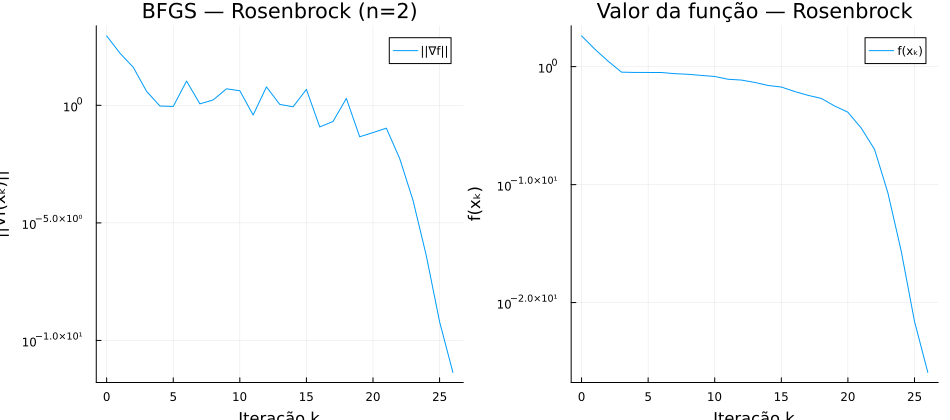

In [6]:
# Algoritmo 13.1 - Quasi-Newton BFGS
# Função de Rosenbrock (n variáveis)
# x₀ = -ones(n), H₀⁻¹ = I, ε = 1e-10

using LinearAlgebra
using Printf
using Plots

# ── Rosenbrock ────────────────────────────────────────────────────────────
function f(x)
    n = length(x)
    return sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:n-1)
end

function ∇f(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i]   += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] +=  200*(x[i+1] - x[i]^2)
    end
    return g
end

# ── Line Search (Alg. 11.5 — Wolfe) ──────────────────────────────────────
function line_search(f, ∇f, x, d; α₀=1.0, β₁=1e-4, β₂=0.99, λ=2.0)
    slope = ∇f(x)' * d
    slope >= 0 && error("d não é direção de descida")
    αl = 0.0; αr = Inf; α = α₀; fx = f(x)
    for _ in 1:500
        ok_a = f(x + α*d) <= fx + β₁*α*slope
        ok_c = ∇f(x + α*d)'*d >= β₂*slope
        ok_a && ok_c && return α
        if !ok_a
            αr = α; α = (αl + αr) / 2.0
        else
            αl = α; α = αr < Inf ? (αl + αr) / 2.0 : λ*α
        end
    end
    return α
end

# ── Atualização BFGS (fórmula corrigida) ─────────────────────────────────
function bfgs_update(Hinv, d, y)
    dy = d' * y
    if abs(dy) < 1e-14
        @warn "dᵀy ≈ 0 — pulando atualização BFGS"
        return Hinv
    end
    n = length(d)
    I = Matrix{Float64}(LinearAlgebra.I, n, n)
    A = I - (d * y') / dy
    B = I - (y * d') / dy
    return A * Hinv * B + (d * d') / dy
end

# ── Algoritmo 13.1 — BFGS ────────────────────────────────────────────────
n     = 2                                              # dimensão
x     = -ones(n)                                       # x₀ = [-1, -1]
Hinv  = Matrix{Float64}(LinearAlgebra.I, n, n)        # H₀⁻¹ = I
ε     = 1e-10
k     = 0
maxiter = 10000

ks    = Int[]
norms = Float64[]
fvals = Float64[]

println("=== Algoritmo 13.1 — BFGS — Rosenbrock (n=$n) ===")
println("x₀ = ", x, "  f(x₀) = ", f(x), "\n")
println("k \t\t ||∇f(xk)|| \t\t f(xk)")

push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
@printf("%d \t\t %+.8E \t\t %+.8E\n", k, norm(∇f(x)), f(x))

while norm(∇f(x)) >= ε && k < maxiter

    g = ∇f(x)
    d = -Hinv * g

    # Segurança: reset se d não for descida
    if ∇f(x)' * d >= 0
        d    = -g
        Hinv = Matrix{Float64}(LinearAlgebra.I, n, n)
        println("  ⚠️  Reset Hinv em k=$k")
    end

    αk    = line_search(f, ∇f, x, d)
    x_new = x + αk * d
    dk    = x_new - x
    yk    = ∇f(x_new) - ∇f(x)
    Hinv  = bfgs_update(Hinv, dk, yk)
    x     = x_new
    k    += 1

    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))

    if k <= 10 || k % 50 == 0
        @printf("%d \t\t %+.8E \t\t %+.8E\n", k, norm(∇f(x)), f(x))
    end
end

println("⋮")
@printf("%d \t\t %+.8E \t\t %+.8E\n", k, norm(∇f(x)), f(x))

println("\n=== Resultado ===")
println("x*    = ", round.(x, digits=8))
println("f(x*) = ", f(x))
println("Solução esperada: x* = [1, 1],  f* = 0")
println("Erro ||x* - 1|| = ", norm(x .- 1))
println("Convergiu em $k iterações")

# ── Gráficos ──────────────────────────────────────────────────────────────
p1 = plot(ks, norms,
    seriestype=:line, xlabel="Iteração k", ylabel="||∇f(xₖ)||",
    title="BFGS — Rosenbrock (n=$n)", yscale=:log10,
    yformatter=:scientific, label="||∇f||", legend=:topright)

p2 = plot(ks, fvals,
    seriestype=:line, xlabel="Iteração k", ylabel="f(xₖ)",
    title="Valor da função — Rosenbrock", yscale=:log10,
    yformatter=:scientific, label="f(xₖ)", legend=:topright)

plot(p1, p2, layout=(1,2), size=(950,420))